# Diversity assessment

## Foreword
Biological diversity, or biodiversity, encompasses the entire variety of life within an ecosystem, spanning genetic variation, species richness, and the complex functional roles organisms play. In the context of tropical forests—the Earth’s most complex terrestrial biomes—biodiversity is not merely a count of species but a measure of ecosystem resilience and evolutionary potential. As noted by Noss (1990), a comprehensive assessment must consider a hierarchy of composition, structure, and function, where the physical measurements of a stand serve as vital indicators of its broader biological health. To quantify this complexity, ecologists rely on Alpha Diversity indices, which measure diversity at a local scale within a single community. While Species Richness ($S$) provides a fundamental count, indices like Shannon-Wiener ($H'$) and Simpson’s ($D$)—as detailed by Magurran (2004)—offer a more nuanced view by incorporating "evenness," or the distribution of individuals among species.In tropical forest assessments, these indices are indispensable tools for identifying "hotspots" of high conservation value and monitoring the impacts of land-use change. Furthermore, the application of Jost’s (2006) concept of "True Diversity" and the mathematical frameworks for sampling estimation by Chao et al. (2014) allow for the standardization of data across different forest plots. By applying these rigorous mathematical frameworks to inventory data, foresters move beyond qualitative observations to produce comparable metrics. This data-driven approach ensures that management interventions prioritize areas of maximum biological complexity, maintaining the intricate web of life that sustains tropical climate regulation and nutrient cycling.

## 1. Import libraries

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp
from inventory_data import load_inventory

## 2. Data import and tidying

In [100]:
df = load_inventory()

## 3. Speciation curves

First of all, it is important to count the unique tree species per sampling plot for each forest line. However, we should know how many of these cannot repeat in the sequent sample plots and based on this build the speciation curves that will illustrate the trend of changes of number of tree species in function of sampled area. As a rule we could say that the more area we sample, the less repeated tree species number we find but there can be exceptions to this rule and here we will observe the trend that can be found for tropical forests.

In [101]:
# 1. Group by 'Line Number' and 'Plot'
# 2. Count unique 'Scientific name' in each group
species_per_plot = df.groupby(["Line Number", "Plot"], observed=True)["Scientific name"].nunique().reset_index()

# Rename the column for clarity
species_per_plot.columns = ["Line Number", "Plot", "Species Count"]

# Display the result
print(species_per_plot)

   Line Number Plot  Species Count
0            1    1             36
1            1    2             37
2            1    3             30
3            1    4             45
4            1    5             32
..         ...  ...            ...
84           7   85             36
85           7   86             32
86           7   87             23
87           7   88             31
88           7   89             36

[89 rows x 3 columns]


In [102]:
# 1. Aggregate unique scientific names into sets for each (Line Number, Plot)
species_per_plot = (
    df.groupby(["Line Number", "Plot"], observed=True)["Scientific name"]
    .unique()
    .apply(set)
    .reset_index()
)

# 2. Ensure sorting
species_per_plot = species_per_plot.sort_values(["Line Number", "Plot"])

# 3. Define function for "First-time Discovery" only
def count_unique_non_repeating_in_line(group):
    seen_species = set()  # Keeps track of everything seen in the line so far
    unique_new_counts = []
    
    for current_plot_species in group["Scientific name"]:
        # Species in this plot MINUS everything we saw in previous plots of this line
        new_species = current_plot_species - seen_species
        
        unique_new_counts.append(len(new_species))
        
        # Update the 'seen' set with the species from the current plot
        seen_species.update(current_plot_species)
            
    group["Tree species"] = unique_new_counts
    return group

# 4. Apply the logic independently per Line
final_counts = (
    species_per_plot.groupby("Line Number", observed=True)
    .apply(count_unique_non_repeating_in_line)
    .reset_index(drop=True)
)

result_table = final_counts[["Line Number", "Plot", "Tree species"]]
print(result_table)

   Line Number Plot  Tree species
0            1    1            36
1            1    2            10
2            1    3             2
3            1    4            14
4            1    5             3
..         ...  ...           ...
84           7   85             3
85           7   86             9
86           7   87             0
87           7   88             3
88           7   89             5

[89 rows x 3 columns]


C:\Users\migue\AppData\Local\Temp\ipykernel_18688\532683289.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(count_unique_non_repeating_in_line)


In [103]:
# 1. Reuse the logic from the previous step to get the 'final_counts' dataframe
# (Assuming 'final_counts' contains: Line Number, Plot, New Scientific Names)

# 2. Calculate the Cumulative New Species and Cumulative Area per Line
# We use groupby to ensure cumulative counts don't bleed between lines
final_counts["Accumulated Tree species"] = (
    final_counts.groupby("Line Number", observed=True)["Tree species"]
    .cumsum()
)

# 3. Calculate Accumulated Area (Plot area = 0.5 ha)
# We count the plots processed so far in each line and multiply by 0.5
final_counts["Accumulated Area [ha]"] = (
    final_counts.groupby("Line Number", observed=True).cumcount() + 1
) * 0.5

# 4. Sort the result by "Tree species" in descending order
sorted_results = final_counts.sort_values(
    by="Tree species", 
    ascending=False
)

# 5. Display the final table
print(sorted_results[[
    "Line Number", 
    "Plot", 
    "Tree species", 
    "Accumulated Tree species", 
    "Accumulated Area [ha]"
]])

   Line Number Plot  Tree species  Accumulated Tree species  \
66           6   67            42                        42   
49           4   50            37                        37   
0            1    1            36                        36   
31           3   32            35                        35   
78           7   79            35                        35   
..         ...  ...           ...                       ...   
43           3   44             0                        75   
77           6   78             0                        77   
76           6   77             0                        77   
74           6   75             0                        74   
73           6   74             0                        74   

    Accumulated Area [ha]  
66                    0.5  
49                    0.5  
0                     0.5  
31                    0.5  
78                    0.5  
..                    ...  
43                    6.5  
77                 

C:\Users\migue\AppData\Local\Temp\ipykernel_18688\2898570313.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for line_id, group in sorted_results.groupby("Line Number"):


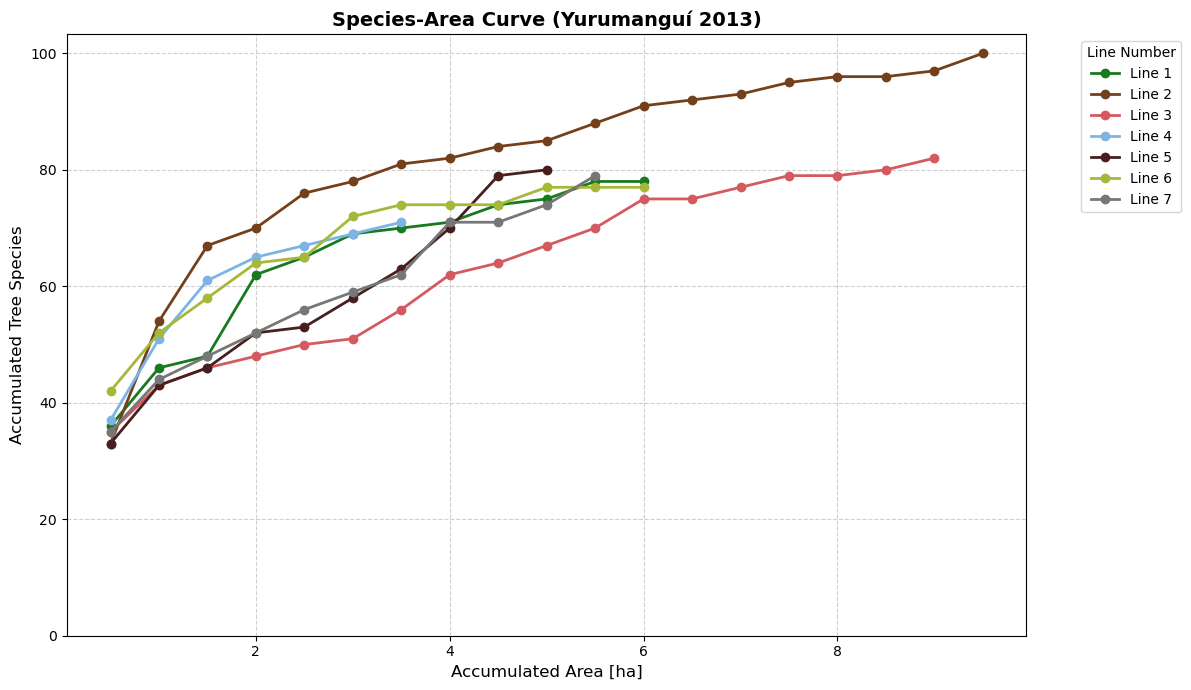

In [104]:
# Your color dictionary
dict_line = {
    1: "#187a1e",
    2: "#74401b",
    3: "#d45a60",
    4: "#7db4e6",
    5: "#481e1e",
    6: "#a5b837",
    7: "#777777",
}

# 5. Visualization: Species-Area Curve with Custom Colors
plt.figure(figsize=(12, 7))

# Ensure Line Number is treated as an integer for the dictionary lookup
for line_id, group in sorted_results.groupby("Line Number"):
    # Sort group by area to ensure the line plots correctly
    plot_group = group.sort_values("Accumulated Area [ha]")
    
    # Get color from dictionary (defaults to black if ID is missing)
    line_color = dict_line.get(int(line_id), "black")
    
    plt.plot(
        plot_group["Accumulated Area [ha]"], 
        plot_group["Accumulated Tree species"], 
        marker='o', 
        linestyle='-', 
        linewidth=2,
        markersize=6,
        label=f'Line {line_id}',
        color=line_color
    )

# Formatting the plot
plt.title("Species-Area Curve (Yurumanguí 2013)", fontsize=14, fontweight='bold')
plt.xlabel("Accumulated Area [ha]", fontsize=12)
plt.ylabel("Accumulated Tree Species", fontsize=12)
plt.ylim(bottom=0)
# Place legend outside of the plot area for better visibility
plt.legend(title="Line Number", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The Species-Area Curve provides a critical visualization of how tree species richness accumulates as the sampled area increases across the seven study lines. All lines follow a characteristic logarithmic progression—rapid initial gains in species followed by a gradual leveling off—which indicates that the sampling effort was sufficient to capture the majority of the local floristic diversity. Line 2 (the brown line) emerges as the most biologically diverse site, reaching a peak of 100 accumulated species over nearly 10 hectares, followed by Line 3, which shows a slower but steady climb. Conversely, Lines 1, 6, and 7 appear to reach their diversity "plateau" much earlier, around 6 hectares, suggesting a more homogenous species composition where fewer new species are discovered as the area expands. From a conservation standpoint, these curves identify Line 2 as a high-priority "diversity hub," while the varying slopes across the lines illustrate that the forest's richness is not evenly distributed, requiring a landscape-level approach to protect the full spectrum of its botanical heritage.

## 4. Diversity indexes

Alpha diversity ($\alpha$-diversity) is defined as the mean species diversity in a site at a local scale. It represents the number of species (richness) and their relative abundance (evenness) within a single, defined community or ecosystem. Core Components of Alpha Diversity:

 * Richness: The total count of different species present in the sample area. 

 * Evenness: The degree to which individuals are distributed among the species. A site where one species makes up 90% of the trees has lower alpha diversity than a site where each species has a similar number of individuals.

The term was originally coined by Whittaker (1960) to distinguish local diversity from Beta diversity (the change in species composition between sites) and Gamma diversity (the total diversity of the entire landscape). According to Magurran (2004), alpha diversity is the most common metric used in conservation biology to identify specific "hotspots" that require protection or to monitor how a local community responds to environmental disturbances.

### 4.1 Richness

In ecology, Species Richness is defined as the total number of unique species present within a specific geographic area, community, or defined sampling unit. Unlike more complex measures of diversity, richness is a qualitative count that does not account for the relative abundance or "evenness" of those species. According to the foundational framework established by Magurran (2004), richness represents the simplest and most fundamental measure of biological diversity, serving as a baseline indicator of the taxonomic variety supported by a particular habitat. While it provides a direct snapshot of biological "wealth," academic consensus (e.g., Gotelli & Colwell, 2001) emphasizes that richness is highly sensitive to sampling effort, often requiring standardized curves to accurately compare different ecosystems.

In [105]:
# Count of tree species per line
species_per_line = (
    df.groupby(["Line Number"], observed=True)["Scientific name"]
    .nunique()
    .reset_index(name="Tree species")
)

species_per_line["Number of trees"] = df.groupby("Line Number", observed=True)["Tree number"].nunique().values
print(species_per_line)

  Line Number  Tree species  Number of trees
0           1            78              257
1           2            99              275
2           3            82              237
3           4            71              150
4           5            80              130
5           6            77              211
6           7            79              153


#### 4.1.1 Margalef

The Margalef Diversity Index ($D_{mg}$) is a measure of species richness that attempts to compensate for the effects of sample size. In biological inventories, larger samples naturally tend to contain more species simply because more individuals are captured; the Margalef index addresses this by relating the total number of species ($S$) to the natural logarithm of the total number of individuals ($N$).

According to Margalef (1958), the index was originally designed to reflect the "information content" or complexity of a biological community. In modern forestry, Magurran (2004) notes that while it has been largely superseded by more robust measures like the Shannon index for formal statistical modeling, it remains highly valuable for a quick, intuitive assessment of taxanomic "wealth" relative to the density of the stand.

$$ D_{Mg}=\frac{S-1}{\ln(N)} $$

$\large D_{Mg}: $ Margalef richness index.

$\large S: $ Number of tree species.

$\large N: $ Total number of trees.

In [106]:
species_per_line["Margalef Index"] = (species_per_line["Tree species"] - 1) / np.log(species_per_line["Number of trees"])
print(species_per_line)

  Line Number  Tree species  Number of trees  Margalef Index
0           1            78              257       13.876184
1           2            99              275       17.447747
2           3            82              237       14.813297
3           4            71              150       13.970284
4           5            80              130       16.229983
5           6            77              211       14.200675
6           7            79              153       15.505608


#### 4.1.2 Menhinick

The Menhinick Index ($D_{Mn}$) is a measure of species richness that, like the Margalef index, attempts to relate the number of species to the total number of individuals in a sample. However, it uses a different mathematical relationship, specifically the square root of the total sample size (N).

In a tropical forest context, the Menhinick index provides a ratio of "species per unit of individual density." Because it uses a square root in the denominator, it reduces the influence of very large sample sizes more aggressively than a linear ratio, but less so than the logarithmic approach used by Margalef.According to Magurran (2004), the Menhinick index is particularly useful when comparing samples of vastly different sizes, although it assumes that the relationship between $S$ and $\sqrt{N}$ remains constant—an assumption that rarely holds true in extremely diverse tropical systems.

The index was originally proposed by Menhinick (1964) in the journal Scientific American as a simplified method for estimating diversity in field biology. While modern researchers often prefer Rarefaction or Hill Numbers (as discussed by Chao et al., 2014) for formal publications, the Menhinick index remains a staple in forest inventory reports for its ease of calculation and intuitive reflection of taxonomic "richness" relative to the physical density of the stand.

$$ D_{Mn}=\frac{S}{\sqrt{N}} $$

$\large D_{Mn}: $ Menhinick richness index.

$\large S: $ Number of tree species.

$\large N: $ Total number of trees.

In [107]:
species_per_line["Menhinick Index"] = (species_per_line["Tree species"]) / np.sqrt(species_per_line["Number of trees"])
print(species_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index
0           1            78              257       13.876184         4.865506
1           2            99              275       17.447747         5.969925
2           3            82              237       14.813297         5.326472
3           4            71              150       13.970284         5.797126
4           5            80              130       16.229983         7.016464
5           6            77              211       14.200675         5.300899
6           7            79              153       15.505608         6.386771


#### 4.1.3 Holdridge

The Holdridge Mixing Ratio ($M$), also known as the Holdridge Complexity Ratio or Humid Mixture, is a specific ecological metric designed to quantify the relationship between species richness and individual density within a forest stand. In his foundational work on life zones, Holdridge (1967) proposed this ratio as a way to measure the "richness of the mixture," defined as the number of unique species ($S$) divided by the total number of individuals ($N$) in a given sample.

In tropical forest ecology, the mixing ratio is often expressed in a "1:X" format, where 1 represents a single species and X represents the number of trees one would expect to count before encountering a new species. For example, a ratio of $1:5$ suggests a highly diverse environment, whereas a ratio of $1:50$ indicates a stand dominated by fewer species. According to Holdridge *et al.* (1971), this ratio is particularly sensitive to the successional stage of the forest; mature, primary tropical forests typically exhibit a much higher mixing ratio than secondary forests or plantations, as they maximize niche differentiation and minimize species dominance.

$$M = \frac{S}{N}$$

$\large M: $ Holdridge mixing ratio.

$\large S: $ Number of tree species.

$\large N: $ Total number of trees.

In [108]:
def calculate_mixing_ratio(S, N):
    # S: Number of species, N: Number of individuals
    return round(S / N, 4) if N > 0 else 0

# 1. Calculate the decimal ratio
species_per_line["Mixing Ratio"] = species_per_line.apply(
    lambda row: calculate_mixing_ratio(row["Tree species"], row["Number of trees"]), 
    axis=1
)

# 2. Calculate the "X" value (1 / decimal ratio)
inverse_ratio = (1 / species_per_line["Mixing Ratio"]).round(0).astype(int)

# 3. Format as a string "1:X" using vectorized string concatenation
species_per_line["Holdridge Mixing Ratio"] = "1:" + inverse_ratio.astype(str)
species_per_line = species_per_line.drop(["Mixing Ratio"], axis=1)
print(species_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

  Holdridge Mixing Ratio  
0                    1:3  
1                    1:3  
2                    1:3  
3                    1:2  
4                    1:2  
5                    1:3  
6                    1:2  


The diversity index table reveals a clear distinction between taxonomic richness and species concentration across the seven lines. While Line 2 is the absolute leader in total richness with 99 species and the highest Margalef Index (17.45), indicating it is the primary genetic reservoir of the study area, it is Line 5 that exhibits the highest species density relative to its population. With a Menhinick Index of 7.02 and a 1:2 Holdridge Mixing Ratio, Line 5 proves to be the most "concentrated" site, where nearly every second tree belongs to a different species despite having the second-lowest tree count (130). Conversely, Line 1 represents the most "homogenous" stand, yielding the lowest scores in both the Margalef (13.88) and Menhinick (4.87) scales, which suggests a higher degree of species dominance. Ultimately, the data identifies Line 2 as the most complex community overall, while Lines 4, 5, and 7 stand out for their high mixing efficiency, representing critical high-diversity niches within the broader forest matrix.

### 4.2 Eveness
In ecology, evenness (also referred to as equitability) measures how similar the abundances of different species are within a community. While "richness" tells you how many species are present, evenness tells you if the "wealth" of individuals is distributed fairly or if a few species are hoarding all the space.

Evenness is a critical health indicator because a forest with high evenness is generally more resilient; if a disease hits one species, the other species are already well-established enough to maintain the ecosystem's functions.

#### 4.2.1 Shannon-Wiener

The Shannon-Wiener Diversity Index ($H'$) is a mathematical measure used in ecology to quantify the "uncertainty" or complexity of a community’s species composition. Unlike simple species richness, which only counts the number of species ($S$), the Shannon index incorporates evenness—the relative abundance of each species within the sample.

According to Magurran (2004), the Shannon index is one of the most widely used diversity metrics because it is sensitive to the presence of rare species, which are often the primary concern in conservation biology. However, Jost (2006) points out that $H'$ is an "entropy" measure, not a direct count of species, leading many modern researchers to convert it into "Effective Number of Species" (or Hill Numbers) to make comparisons between sites more intuitive.

$$ H'=-\sum_{}^{}p_{i}\ln(p_{i}) $$

$$ p_{i} = \frac{n_{i}}{N} $$

$\large S: $ Total number of species.

$\large N: $ Total number of trees.

$\large n_{i}: $ Number of trees for each *i* tree species.

$\large p_{i}: $ The proportion of individuals belonging to the *i*-th species.

Once again, we will calculate abundance per tree species just as it was done in the [IVI Notebook](https://github.com/miguelif92/IVI-ForstEcol/blob/main/notebook/1_ivi.ipynb). The first thing is to count the number of trees per tree species, calculate the relative abundance and we will end with calculation of Shannon-Wiener components per tree species that will be the multiplication of each relative abundance with the natural logarithm.

In [109]:
# 1. Calculate the number of trees per tree species
abundance_per_line_per_sp = (
    df.groupby(["Line Number", "Scientific name"], observed=True)["Tree number"]
    .nunique()
    .reset_index(name="Number of trees")
)

# 2. Calculate relative abundance per species within each line
abundance_per_line_per_sp["Relative abundance"] = (
    abundance_per_line_per_sp["Number of trees"] / 
    abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')
)

# 3. Calculate the Shannon Index component for each species
abundance_per_line_per_sp["Shannon Index Component"] = (
    abundance_per_line_per_sp["Relative abundance"] *np.log(abundance_per_line_per_sp["Relative abundance"])
)

print(abundance_per_line_per_sp)

    Line Number           Scientific name  Number of trees  \
0             1         Aegiphila grandis                1   
1             1       Anacardium excelsum               30   
2             1             Apeiba aspera                7   
3             1  Astrocaryum standleyanum                9   
4             1      Basiloxylon excelsum                1   
..          ...                       ...              ...   
561           7               Vatairea sp               14   
562           7                Virola spp               36   
563           7                Xilopia sp                9   
564           7    Zanthoxylon rhoifolium                2   
565           7                        nn               42   

     Relative abundance  Shannon Index Component  
0              0.000565                -0.004223  
1              0.016940                -0.069081  
2              0.003953                -0.021871  
3              0.005082                -0.026843  


C:\Users\migue\AppData\Local\Temp\ipykernel_18688\3098945100.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')


Let's calculate the Shannon-Wiener index by summing the components.

In [110]:
# 1. Sum the Shannon Index components per line to get the total Shannon Index
shannon_index_per_line = (
    abundance_per_line_per_sp.groupby("Line Number", observed=True)["Shannon Index Component"]
    .sum()
    .reset_index(name="Shannon Index")
)
shannon_index_per_line["Shannon Index"] = -shannon_index_per_line["Shannon Index"]
print(shannon_index_per_line)

  Line Number  Shannon Index
0           1       3.600484
1           2       3.856282
2           3       3.754718
3           4       3.744202
4           5       3.664648
5           6       3.771379
6           7       3.805867


From now on, we will focus on grouping and combining all the indexes in a single dataframe for a better data management.

In [111]:
# Combine all diversity metrics into a single DataFrame for easier comparison
lines = species_per_line['Line Number']
species = species_per_line['Tree species']
trees = species_per_line['Number of trees']
margalef = pd.to_numeric(species_per_line['Margalef Index'], errors='coerce')
menhinick = pd.to_numeric(species_per_line['Menhinick Index'], errors='coerce')
holdridge = species_per_line['Holdridge Mixing Ratio']
shannon = shannon_index_per_line['Shannon Index']

div_per_line = pd.DataFrame({
    'Line Number': lines,
    'Tree species': species,
    'Number of trees': trees,
    'Margalef Index': margalef,
    'Menhinick Index': menhinick,
    'Holdridge Mixing Ratio': holdridge,
    'Shannon Index': shannon
})

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

  Holdridge Mixing Ratio  Shannon Index  
0                    1:3       3.600484  
1                    1:3       3.856282  
2                    1:3       3.754718  
3                    1:2       3.744202  
4                    1:2       3.664648  
5                    1:3       3.771379  
6                    1:2       3.805867  


#### 4.2.2 Pielou
The Pielou Evenness Index ($E$) is a measure used in ecology to quantify how equally individuals are distributed among the species present in a community. While richness indices (like Margalef or Menhinick) tell you how many species there are, Pielou’s index tells you if the community is dominated by one or two species or if all species are represented by a similar number of individuals.Mathematically, it is calculated as the ratio of the observed Shannon-Wiener diversity ($H'$) to the maximum possible diversity ($H'_{max}$) that could exist if every species had the exact same number of individuals.

Proposed by E.C. Pielou (1966), this index is the standard "evenness" metric in forest inventories. According to Magurran (2004), Pielou's $E$ is essential because it allows researchers to separate the "richness" component of diversity from the "abundance" component, providing a clearer picture of ecosystem stability and successional stage.

$$ E =\frac{H'}{H'_{max}} $$

$$ E =\frac{H'}{\ln(S)} $$

$\large H': $ Shannon-Wiener Index.

$\large S: $ Total number of species.

In [112]:
# Calculate Pielou's Evenness Index
div_per_line["Pielou Index"] = div_per_line["Shannon Index"] / np.log(div_per_line["Tree species"])

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

  Holdridge Mixing Ratio  Shannon Index  Pielou Index  
0                    1:3       3.600484      0.826423  
1                    1:3       3.856282      0.839212  
2                    1:3       3.754718      0.852044  
3                    1:2       3.744202      0.878368  
4                    1:2       3.664648      0.836291  
5              

#### 4.2.2 Simpson

Simpson’s Diversity Index ($D_{S}$) is a mathematical measure that calculates the probability that two individuals randomly selected from a sample will belong to the same species. Unlike the Shannon-Wiener index, which is more sensitive to rare species, Simpson’s index is heavily weighted toward the abundance of the most common (dominant) species.

Originally proposed by Edward H. Simpson (1949), this index is considered one of the most robust measures of diversity because it is less affected by sample size than the Shannon index. According to Magurran (2004), it is the preferred metric when the goal of the study is to understand the influence of common species on ecosystem function rather than the presence of rare "hidden" biodiversity.

$$ D_{S} =\sum_{}^{}p^{2}_{i} $$

$$ D_{S} =\sum_{}^{}\frac{n_{i}(n_{i}-1))}{N(N-1)} $$

$\large N: $ Total number of trees.

$\large n_{i}: $ Number of trees for each *i* tree species.

$\large p_{i}: $ The proportion of individuals belonging to the *i*-th species.

In [113]:
# 1. Calculate n(n-1) for each species row
# This is the numerator component for each species
abundance_per_line_per_sp["n_component"] = (
    abundance_per_line_per_sp["Number of trees"] * (abundance_per_line_per_sp["Number of trees"] - 1)
)

# 2. Calculate N (Total trees per line) and the N(N-1) denominator
# We use transform('sum') so the value is available on every row for the calculation
abundance_per_line_per_sp["N_total"] = abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')
abundance_per_line_per_sp["N_component"] = abundance_per_line_per_sp["N_total"] * (abundance_per_line_per_sp["N_total"] - 1)

# 3. Calculate the individual probability for each species
abundance_per_line_per_sp["Species_D_Value"] = abundance_per_line_per_sp["n_component"] / abundance_per_line_per_sp["N_component"]

# 4. Final Simpson Index (D) per line: Sum the species components
# This creates a summary table with one row per line
simpson_summary = abundance_per_line_per_sp.groupby("Line Number")["Species_D_Value"].sum().reset_index()
simpson_summary.columns = ["Line Number", "Simpson Index (D)"]


print(simpson_summary)

  Line Number  Simpson Index (D)
0           1           0.035193
1           2           0.029100
2           3           0.031475
3           4           0.030907
4           5           0.038638
5           6           0.030447
6           7           0.027355


C:\Users\migue\AppData\Local\Temp\ipykernel_18688\1402830044.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abundance_per_line_per_sp["N_total"] = abundance_per_line_per_sp.groupby("Line Number")["Number of trees"].transform('sum')
C:\Users\migue\AppData\Local\Temp\ipykernel_18688\1402830044.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  simpson_summary = abundance_per_line_per_sp.groupby("Line Number")["Species_D_Value"].sum().reset_index()


In [114]:
lines = species_per_line['Line Number']
species = species_per_line['Tree species']
trees = species_per_line['Number of trees']
margalef = pd.to_numeric(species_per_line['Margalef Index'], errors='coerce')
menhinick = pd.to_numeric(species_per_line['Menhinick Index'], errors='coerce')
holdridge = species_per_line['Holdridge Mixing Ratio']
shannon = shannon_index_per_line['Shannon Index']
pielou = pd.to_numeric(div_per_line['Pielou Index'], errors='coerce')
simpson = simpson_summary['Simpson Index (D)']

div_per_line = pd.DataFrame({
    'Line Number': lines,
    'Tree species': species,
    'Number of trees': trees,
    'Margalef Index': margalef,
    'Menhinick Index': menhinick,
    'Holdridge Mixing Ratio': holdridge,
    'Shannon-Wiener Index': shannon,
    'Pielou Index': pielou,
    'Simpson Index': simpson,
})

print(div_per_line)

  Line Number  Tree species  Number of trees  Margalef Index  Menhinick Index  \
0           1            78              257       13.876184         4.865506   
1           2            99              275       17.447747         5.969925   
2           3            82              237       14.813297         5.326472   
3           4            71              150       13.970284         5.797126   
4           5            80              130       16.229983         7.016464   
5           6            77              211       14.200675         5.300899   
6           7            79              153       15.505608         6.386771   

  Holdridge Mixing Ratio  Shannon-Wiener Index  Pielou Index  Simpson Index  
0                    1:3              3.600484      0.826423       0.035193  
1                    1:3              3.856282      0.839212       0.029100  
2                    1:3              3.754718      0.852044       0.031475  
3                    1:2              3

Calculation an analysis of biodiversity based on indices reveal that Line 2 is the undisputed "diversity reservoir," boasting the highest species richness (99) and Margalef Index (17.45), marking it as the most structurally complex site. However, Line 5 represents the most "concentrated" mixture, achieving a high species count with the fewest individuals, as evidenced by its leading Menhinick Index (7.02) and a 1:2 Holdridge Mixing Ratio. While Line 2 has more total species, Line 4 displays the most balanced community structure with the highest Pielou Evenness (0.88), indicating a lack of species dominance. In contrast, Line 1 emerges as the most homogenous stand, recording the lowest scores across the Shannon-Wiener (3.60) and Pielou indices, which suggests a forest dominated by a smaller group of common species. Ultimately, these metrics identify a trade-off between absolute richness in Line 2 and high species-per-individual efficiency in Line 5, with Line 4 representing the most "democratic" distribution of botanical variety.

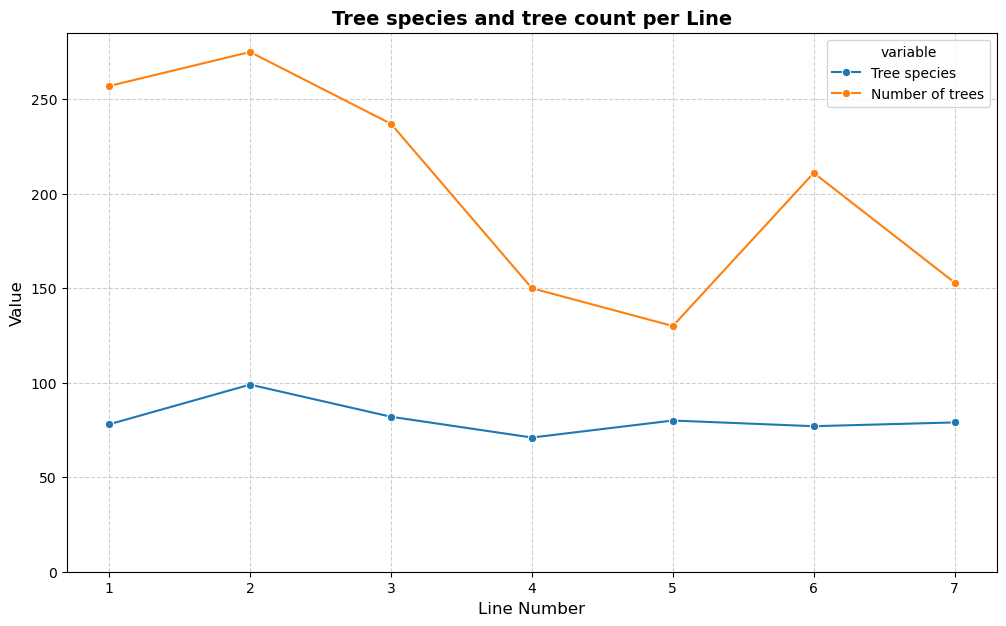

In [115]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=div_per_line.melt(id_vars='Line Number', value_vars=[ "Tree species", "Number of trees"]), x='Line Number', y='value', hue='variable', marker='o')
plt.title("Tree species and tree count per Line", fontsize=14, fontweight='bold')
plt.xlabel("Line Number", fontsize=12) 
plt.ylabel("Value", fontsize=12)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The previous figure illustrates a significant decoupling between sample size and species richness across the seven study lines. While Line 2 represents the quantitative peak of the dataset—boasting the highest number of trees (275) and the highest species count (99)—the most ecologically telling segment occurs between Line 4 and Line 5. In this transition, the "Number of trees" reaches its lowest point in the entire study (130), yet the "Tree species" count actually trends upward to 80; this narrowing gap visually confirms that Line 5 is the most "efficient" or concentrated sample, capturing more diversity with fewer individuals. Conversely, the wide vertical distance between the two variables in Line 1 and Line 6 highlights a higher degree of species redundancy, where a large population of trees is distributed among relatively fewer taxa, suggesting these areas are dominated by a small group of common species rather than a diverse mix.

C:\Users\migue\AppData\Local\Temp\ipykernel_18688\455105701.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[idx].values for name, group in div_per_line.groupby('Line Number')]


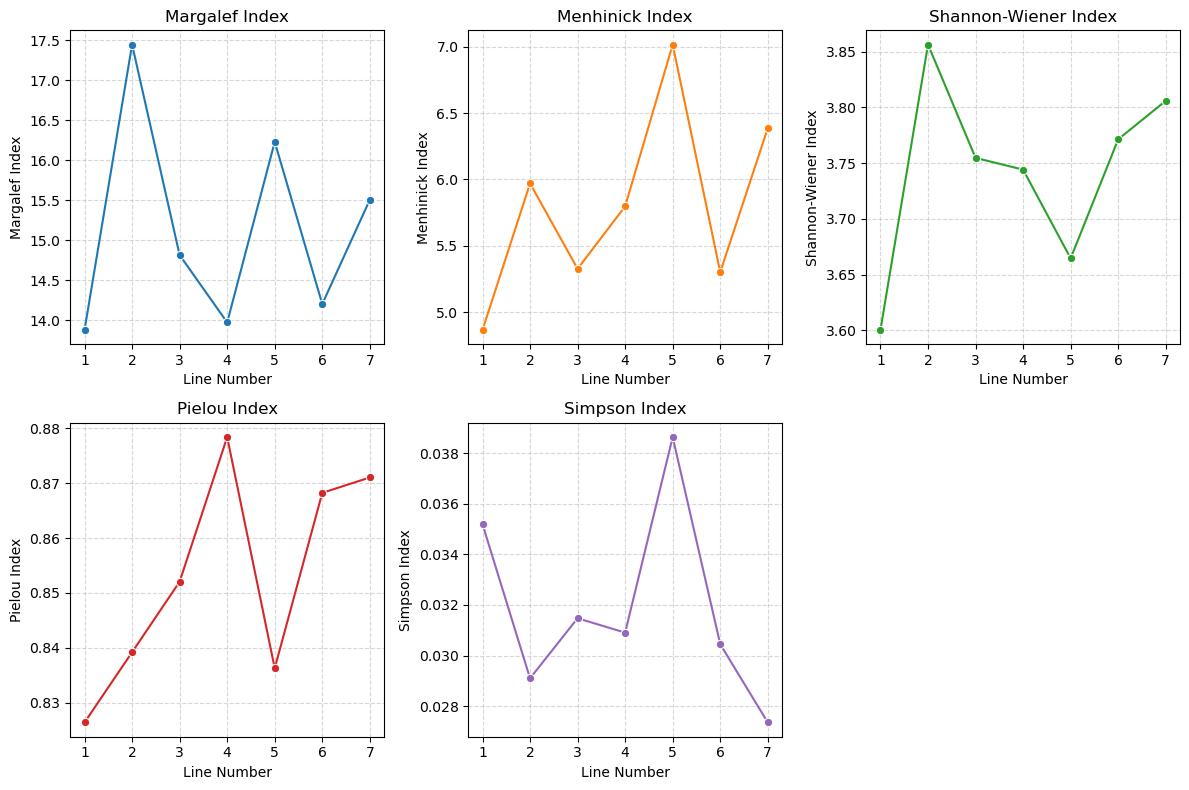

In [116]:
# Note: Based on your image, I'll assume 'Line Number' refers to your different forest sites/types.
# Ensure you have multiple rows (samples) for each site to make the test valid.
indices = ['Margalef Index', 'Menhinick Index', 'Shannon-Wiener Index', 'Pielou Index', 'Simpson Index']

div_dict = {
    'Margalef Index': '#1f77b4',   # Blue
    'Menhinick Index': '#ff7f0e',  # Orange
    'Shannon-Wiener Index': '#2ca02c',    # Green
    'Pielou Index': '#d62728',     # Red
    'Simpson Index': '#9467bd',    # Purple
}

results = []
for idx in indices:
    # We group by 'Line Number' and create a list of data arrays for each group
    groups = [group[idx].values for name, group in div_per_line.groupby('Line Number')]
    

# 2. Visualization
plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices, 1):
    plt.subplot(2, 3, i)
    sns.lineplot(x='Line Number', y=idx, data=div_per_line, color=div_dict[idx], marker='o')
    plt.title(idx)
    plt.xticks()
    plt.grid(True, linestyle='--', alpha=0.5)
    

plt.tight_layout()
plt.show()

Through a comprehensive visualization of the five diversity indices highlights the contrasting ways ecologists measure "biodiversity" across the seven forest lines. Line 2 emerges as the leader in Margalef richness and Shannon complexity, indicating it is the most species-dense and structurally intricate site. However, Line 5 presents a unique ecological signature; it reaches a peak in the Menhinick Index (reflecting high species density per tree) and the Simpson Index (suggesting high dominance), yet it suffers a sharp drop in Pielou Evenness. This indicates that while Line 5 is packed with different species, it is likely dominated by a few very common ones that "crowd out" the abundance of others. In contrast, Line 4 achieves the study's highest Pielou Index, marking it as the most "democratic" or even community, where individuals are distributed most fairly among the species present. Finally, Line 7 shows the highest overall diversity according to the Simpson Index (lowest value on the graph, meaning lowest probability of repeat encounters), suggesting it is the most stable and diverse stand in terms of random species encounters.

The multi-index analysis of the seven forest lines reveals a sophisticated landscape where taxonomic wealth and structural evenness follow distinct spatial patterns. Line 2 stands as the primary ecological anchor, possessing the highest absolute species richness (99) and a dominant Margalef Index (17.45), which characterizes it as the most structurally complex and stable community in the study area. In contrast, Line 5 represents a high-efficiency "diversity hotspot"; despite having a lower total tree count, its leading Menhinick Index (7.02) and 1:2 Holdridge Mixing Ratio indicate an exceptional rate of species turnover, where nearly every second tree encountered belongs to a different taxon.

While Line 2 leads in total species, it is Line 4 that exhibits the most balanced internal architecture, achieving the highest Pielou Evenness (0.878) and a robust Shannon-Wiener Index (3.74), suggesting a community where resources are distributed "democratically" without a single species achieving dominance. Conversely, Line 1 emerges as the most structurally simplified stand, recording the lowest scores across the Shannon-Wiener (3.60) and Pielou (0.826) scales, signaling a higher concentration of common species. Ultimately, these results suggest that while Line 2 is the most critical for broad-spectrum genetic conservation, Lines 4 and 5 represent vital areas of high-density diversity and balanced regeneration that are essential for the forest's long-term resilience.

Biodiversity assessment through ecological indices is a critical decision-making tool in forest management because it transforms raw tree counts into a diagnostic map of ecosystem health and resilience. By analyzing the interplay between taxonomic richness (Margalef/Menhinick) and structural evenness (Shannon/Pielou/Simpson), managers can move beyond a "one-size-fits-all" approach to define specialized conservation zones. For instance, identifying Line 2 as a high-richness "genetic reservoir" justifies its status as a strict protection area to preserve rare species, while recognizing the high evenness of Line 4 provides a benchmark for a stable, resilient forest less vulnerable to pests. Ultimately, these indices allow foresters to prioritize interventions—such as protecting high-turnover "nurseries" like Line 5 or identifying more homogenous stands for sustainable harvesting—ensuring that management actions maintain the delicate balance between biological complexity and long-term forest productivity.

## References

Chao, A., Gotelli, N. J., Hsieh, T. C., Sander, E. L., Ma, K. H., Colwell, R. K., & Ellison, A. M. (2014). Rarefaction and extrapolation with Hill numbers: A framework for sampling and estimation in species diversity studies. *Ecological Monographs, 84*(1), 45-67. [doi:10.1890/13-0133.1](https://esajournals.onlinelibrary.wiley.com/doi/abs/10.1890/13-0133.1)

Holdridge, L. R. (1967). *Life zone ecology*. San José, Costa Rica: Tropical Science Center.

Jost, L. (2006). Entropy and diversity. *Oikos, 113*(2), 363-375 [doi:10.1111/j.2006.0030-1299.14414.x](https://doi.org/10.1111/j.2006.0030-1299.14714.x)

Kent, M. (2011). *Vegetation description and data analysis: A practical approach (2nd ed.).* Oxford, UK: Wiley-Blackwell.

Magurran, A. E. (2004). *Measuring biological diversity.* Oxford, UK: Blackwell Publishing.

Margalef, R. (1958). Information theory in ecology. *General Systems, 3*, 36-71.

Menhinick, E. F. (1964). A comparison of some species-individuals diversity indices applied to samples of field insects. Ecology, 45(4), 859-861. [doi:10.2307/1934933](https://doi.org/10.2307/1934933)

Noss, R. F. (1990). Indicators for monitoring biodiversity: A hierarchical approach. *Conservation Biology, 4*(4), 355-364. [doi:10.1111/j.1523-1739.1990.tb00309.x](https://doi.org/10.1111/j.1523-1739.1990.tb00309.x)

Pielou, E. C. (1966). The measurement of diversity in different types of biological collections. Journal of Theoretical Biology, 13, 131-144. [doi:10.1016/0022-5193(66)90013-0](https://www.sciencedirect.com/science/article/abs/pii/0022519366900130)

Shannon, C. E., & Weaver, W. (1949). *The mathematical theory of communication.* Urbana, IL: University of Illinois Press.

Simpson, E. H. (1949). Measurement of diversity. *Nature, 163*(4148), 688. [doi:10.1038/163688a0](https://www.nature.com/articles/163688a0).

Whittaker, R. H. (1960). Vegetation of the Siskiyou Mountains, Oregon and California. *Ecological Monographs, 30*(3), 279-338. [doi:10.2307/1943563](https://esajournals.onlinelibrary.wiley.com/doi/abs/10.2307/1943563)
